# Week 2 Assignment - IMDb Sentiment Analyser
### WnCC Machine Learning Learner Space 2026

---

In this notebook you will build a **complete sentiment analysis pipeline** - from raw text to a trained neural network - entirely from scratch.

**Your pipeline:**
```
Raw Text → Clean → Tokenise → BoW / TF-IDF → Logistic Regression (baseline)
                                            → MLP (neural network)
                                            → Evaluate with F1, Confusion Matrix
```

**Rules:**
- You may use `numpy`, `matplotlib`, `sklearn` for utilities
- For the MLP section, use **PyTorch** (or NumPy if you prefer)
- Do NOT just call `sklearn.Pipeline` and call it done. Implement the concepts.
- Every `# YOUR CODE HERE` block must be filled in

---
**Run the setup cell first. Then work top to bottom.**

In [13]:
# ========== SETUP ==========
# Run this cell first - it installs dependencies and downloads the dataset

!pip install datasets -q

import numpy as np
import matplotlib.pyplot as plt
import re
import math
from collections import Counter, defaultdict
from datasets import load_dataset

# Load IMDb dataset using the correct identifier
print('Loading IMDb dataset...')
dataset = load_dataset('stanfordnlp/imdb')

# IMPORTANT: Shuffle the dataset because it is sorted by label!
# This ensures our subset contains both Positive and Negative classes.
shuffled_dataset = dataset.shuffle(seed=42)

train_texts = shuffled_dataset['train']['text']
train_labels = shuffled_dataset['train']['label']
test_texts  = shuffled_dataset['test']['text']
test_labels  = shuffled_dataset['test']['label']

# Use a subset for speed
N_TRAIN = 5000
N_TEST  = 1000
train_texts  = train_texts[:N_TRAIN]
train_labels = train_labels[:N_TRAIN]
test_texts   = test_texts[:N_TEST]
test_labels  = test_labels[:N_TEST]

print(f'Loaded {N_TRAIN} training and {N_TEST} test reviews.')
print(f'Classes in training: {np.unique(train_labels)}')
print(f'Sample review: "{train_texts[0][:120]}..."')
print(f'Label: {"Positive" if train_labels[0] == 1 else "Negative"}')

Loading IMDb dataset...
Loaded 5000 training and 1000 test reviews.
Classes in training: [0 1]
Sample review: "There is no relation at all between Fortier and Profiler but the fact that both are police series about violent crimes. ..."
Label: Positive


---
## Part 1 - Text Preprocessing

Raw text is messy. Before any model can use it, we need to:
1. **Lowercase** everything (so "Good" and "good" are the same word)
2. **Remove HTML tags** (IMDb reviews often contain `<br />` etc.)
3. **Remove punctuation** (most of it doesn't carry sentiment)
4. **Tokenise** - split into individual words
5. **Remove stopwords** - extremely common words ("the", "is", "a") that add noise

> 💡 Notice: we are NOT removing all punctuation blindly. Negation words like "n't" matter!

In [20]:
STOPWORDS = set([
    'i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', "you're",
    "you've", "you'll", "you'd", 'your', 'yours', 'yourself', 'he', 'him', 'his',
    'himself', 'she', "she's", 'her', 'hers', 'herself', 'it', "it's", 'its',
    'itself', 'they', 'them', 'their', 'theirs', 'themselves', 'what', 'which',
    'who', 'whom', 'this', 'that', "that'll", 'these', 'those', 'am', 'is', 'are',
    'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'having', 'do',
    'does', 'did', 'doing', 'a', 'an', 'the', 'and', 'but', 'if', 'or', 'because',
    'as', 'until', 'while', 'of', 'at', 'by', 'for', 'with', 'about', 'against',
    'between', 'into', 'through', 'during', 'before', 'after', 'above', 'below',
    'to', 'from', 'up', 'down', 'in', 'out', 'on', 'off', 'over', 'under', 'again',
    'further', 'then', 'once', 'here', 'there', 'when', 'where', 'why', 'how',
    'all', 'both', 'each', 'few', 'more', 'most', 'other', 'some', 'such', 'than',
    'too', 'very', 's', 't', 'can', 'will', 'just', 'should', "should've", 'now',
    'd', 'll', 'm', 'o', 're', 've', 'y', 'ain', 'aren', "aren't", 'couldn',
    "couldn't", 'didn', "didn't", 'doesn', "doesn't", 'hadn', "hadn't", 'hasn',
    "hasn't", 'haven', "haven't", 'isn', "isn't", 'ma', 'mightn', "mightn't",
    'mustn', "mustn't", 'needn', "needn't", 'shan', "shan't", 'shouldn',
    "shouldn't", 'wasn', "wasn't", 'weren', "weren't", 'won', "won't", 'wouldn',
    "wouldn't"
])

def preprocess(text):
    text = text.lower()
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = text.split()
    tokens = [t for t in tokens if t not in STOPWORDS and len(t) > 2]
    return tokens

# Re-preprocessing ensures tokens match the shuffled labels
print('Preprocessing shuffled reviews...')
train_tokens = [preprocess(t) for t in train_texts]
test_tokens  = [preprocess(t) for t in test_texts]

print('Sample tokens (synchronized):', train_tokens[0][:15])

Preprocessing shuffled reviews...
Sample tokens (synchronized): ['relation', 'fortier', 'profiler', 'fact', 'police', 'series', 'violent', 'crimes', 'profiler', 'looks', 'crispy', 'fortier', 'looks', 'classic', 'profiler']


---
## Part 2 - Bag-of-Words Vectoriser

Build a vocabulary from the training data, then convert each review into a count vector.

**Your task:** Complete the `BagOfWords` class below.

In [21]:
# Ensure we use the labels from the shuffled dataset defined in setup
bow = BagOfWords(max_vocab=5000)
X_train_bow = bow.fit_transform(train_tokens)
X_test_bow  = bow.transform(test_tokens)

# Converting the labels to numpy arrays again to ensure they match the current subset
y_train = np.array(train_labels)
y_test  = np.array(test_labels)

print(f'X_train_bow shape: {X_train_bow.shape}')
print(f'Classes in y_train: {np.unique(y_train)}')
print(f'Sparsity: {(X_train_bow == 0).mean():.1%} zeros')

Vocabulary built: 5000 words
X_train_bow shape: (5000, 5000)
Classes in y_train: [0 1]
Sparsity: 98.4% zeros


---
## Part 3 - TF-IDF Vectoriser

Improve on raw counts by weighting words by how informative they are.

**Your task:** Complete the `TFIDF` class.

In [22]:
tfidf = TFIDF(max_vocab=5000)
X_train_tfidf = tfidf.fit_transform(train_tokens)
X_test_tfidf  = tfidf.transform(test_tokens)

print(f'X_train_tfidf shape: {X_train_tfidf.shape}')

TF-IDF vocab size: 5000
X_train_tfidf shape: (5000, 5000)


---
## Part 4 - Evaluation Toolkit

Implement the metrics from scratch. Then use them everywhere.

In [11]:
def confusion_matrix(y_true, y_pred):
    """Returns [[TN, FP], [FN, TP]] for binary classification."""
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    tp = np.sum((y_true == 1) & (y_pred == 1))
    return np.array([[tn, fp], [fn, tp]])

def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

def precision(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    return tp / (tp + fp) if (tp + fp) > 0 else 0

def recall(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    return tp / (tp + fn) if (tp + fn) > 0 else 0

def f1_score(y_true, y_pred):
    p = precision(y_true, y_pred)
    r = recall(y_true, y_pred)
    return 2 * (p * r) / (p + r) if (p + r) > 0 else 0

def plot_confusion_matrix(cm, title='Confusion Matrix'):
    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(['Neg (pred)', 'Pos (pred)'])
    ax.set_yticklabels(['Neg (true)', 'Pos (true)'])
    labels = [['TN', 'FP'], ['FN', 'TP']]
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{labels[i][j]}\n{cm[i,j]}',
                    ha='center', va='center', fontsize=13,
                    color='white' if cm[i,j] > cm.max()/2 else 'black')
    ax.set_title(title, fontsize=14, pad=12)
    plt.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

def evaluate(y_true, y_pred, name='Model'):
    cm = confusion_matrix(y_true, y_pred)
    acc = accuracy(y_true, y_pred)
    p   = precision(y_true, y_pred)
    r   = recall(y_true, y_pred)
    f1  = f1_score(y_true, y_pred)
    print(f'\n===== {name} =====')
    print(f'Accuracy : {acc:.4f}')
    print(f'Precision: {p:.4f}')
    print(f'Recall   : {r:.4f}')
    print(f'F1 Score : {f1:.4f}')
    plot_confusion_matrix(cm, title=name)
    return {'accuracy': acc, 'precision': p, 'recall': r, 'f1': f1}

print('Evaluation toolkit ready!')

Evaluation toolkit ready!


---
## Part 5 - Logistic Regression Baseline

A logistic regression classifier on TF-IDF features. This is your **baseline** - your MLP must beat this.

Training Logistic Regression baseline...

===== Logistic Regression (TF-IDF Baseline) =====
Accuracy : 0.8480
Precision: 0.8243
Recall   : 0.8750
F1 Score : 0.8489


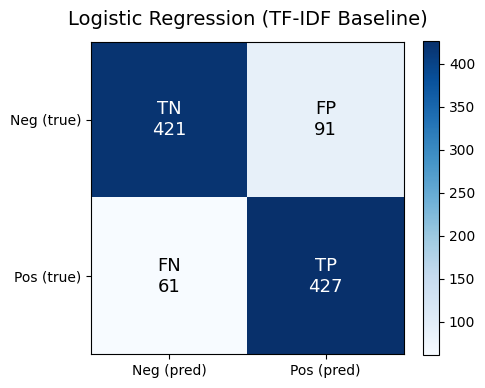

In [23]:
from sklearn.linear_model import LogisticRegression

print('Training Logistic Regression baseline...')
lr = LogisticRegression(max_iter=1000, C=1.0)
lr.fit(X_train_tfidf, y_train)

y_pred_lr = lr.predict(X_test_tfidf)
lr_metrics = evaluate(y_test, y_pred_lr, name='Logistic Regression (TF-IDF Baseline)')

---
## Part 6 - MLP Classifier with PyTorch

Now build a Multi-Layer Perceptron that takes TF-IDF vectors as input and classifies sentiment.

**Architecture:**
```
Input (5000) → Linear → ReLU → Dropout → Linear → ReLU → Dropout → Linear(2) → Softmax
```

In [16]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Convert numpy arrays to PyTorch tensors
X_tr = torch.tensor(X_train_tfidf, dtype=torch.float32)
y_tr = torch.tensor(y_train, dtype=torch.long)
X_te = torch.tensor(X_test_tfidf, dtype=torch.float32)
y_te = torch.tensor(y_test, dtype=torch.long)

train_dataset = TensorDataset(X_tr, y_tr)
train_loader  = DataLoader(train_dataset, batch_size=64, shuffle=True)

# ===== Define the MLP =====
class SentimentMLP(nn.Module):
    def __init__(self, input_dim, hidden1=256, hidden2=128, num_classes=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden2, num_classes)
        )

    def forward(self, x):
        return self.net(x)

model     = SentimentMLP(input_dim=5000)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f'\nTotal trainable parameters: {total_params:,}')

SentimentMLP(
  (net): Sequential(
    (0): Linear(in_features=5000, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=128, out_features=2, bias=True)
  )
)

Total trainable parameters: 1,313,410


In [26]:
# ===== Re-sync Training Tensors and Train MLP =====
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Re-create tensors using the correctly synchronized numpy arrays
X_tr = torch.tensor(X_train_tfidf, dtype=torch.float32)
y_tr = torch.tensor(y_train, dtype=torch.long)

train_dataset = TensorDataset(X_tr, y_tr)
train_loader  = DataLoader(train_dataset, batch_size=64, shuffle=True)

# Reset model and optimizer
model = SentimentMLP(input_dim=5000)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

EPOCHS = 15
train_losses = []
train_accs   = []

print('Starting fresh training with synchronized labels...')
for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0
    correct = 0
    total = 0

    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        logits = model(X_batch)
        loss   = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * len(y_batch)
        preds = logits.argmax(dim=1)
        correct += (preds == y_batch).sum().item()
        total += len(y_batch)

    avg_loss = epoch_loss / total
    avg_acc  = correct / total
    train_losses.append(avg_loss)
    train_accs.append(avg_acc)
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f'Epoch {epoch+1:02d}/{EPOCHS}  Loss: {avg_loss:.4f}  Train Acc: {avg_acc:.4f}')

Starting fresh training with synchronized labels...
Epoch 01/15  Loss: 0.5157  Train Acc: 0.7654
Epoch 05/15  Loss: 0.0077  Train Acc: 0.9988
Epoch 10/15  Loss: 0.0005  Train Acc: 1.0000
Epoch 15/15  Loss: 0.0001  Train Acc: 1.0000



===== MLP (TF-IDF Input) =====
Accuracy : 0.8280
Precision: 0.8198
Recall   : 0.8299
F1 Score : 0.8248


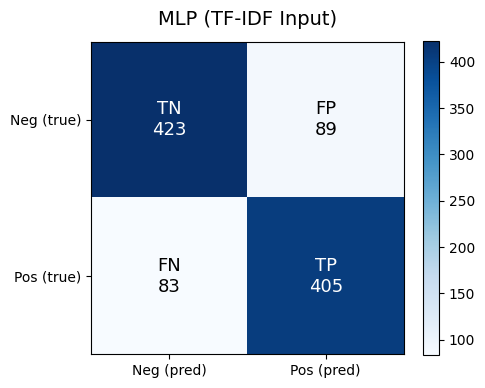

In [27]:
# ===== Re-sync Tensors and Evaluate MLP =====
# Ensure we are using the latest synchronized TF-IDF features and labels
import torch
X_te = torch.tensor(X_test_tfidf, dtype=torch.float32)
y_te = torch.tensor(y_test, dtype=torch.long)

model.eval()
with torch.no_grad():
    logits = model(X_te)
    y_pred_mlp = logits.argmax(dim=1).numpy()

mlp_metrics = evaluate(y_test, y_pred_mlp, name='MLP (TF-IDF Input)')

In [28]:
# ===== Sanity Check =====
print('========== SANITY CHECK ==========')
print(f'Logistic Regression F1: {lr_metrics["f1"]:.4f}')
print(f'MLP F1:                 {mlp_metrics["f1"]:.4f}')

if mlp_metrics['f1'] > 0.70:
    print('✅ PASS: MLP F1 > 0.70')
else:
    print('❌ MLP F1 is below 0.70. Try training for more epochs, tuning hidden sizes, or adjusting learning rate.')

# Quick demo
print('\n===== DEMO =====')
demo_reviews = [
    'This movie was absolutely brilliant. The acting was superb and the story was moving.',
    'Terrible film. Boring, predictable, and a complete waste of time.'
]
for rev in demo_reviews:
    tokens  = preprocess(rev)
    vec     = tfidf.transform([tokens])
    x_demo  = torch.tensor(vec, dtype=torch.float32)
    model.eval()
    with torch.no_grad():
        logit  = model(x_demo)
        prob   = torch.softmax(logit, dim=1)
        pred   = prob.argmax().item()
    label = '😊 Positive' if pred == 1 else '😞 Negative'
    conf  = prob[0, pred].item()
    print(f'  Review: "{rev[:60]}..."')
    print(f'  → Prediction: {label}  (confidence: {conf:.2%})\n')

========== SANITY CHECK ==========
Logistic Regression F1: 0.8489
MLP F1:                 0.8248
✅ PASS: MLP F1 > 0.70

===== DEMO =====
  Review: "This movie was absolutely brilliant. The acting was superb a..."
  → Prediction: 😊 Positive  (confidence: 100.00%)

  Review: "Terrible film. Boring, predictable, and a complete waste of ..."
  → Prediction: 😞 Negative  (confidence: 100.00%)



In [30]:
import pandas as pd
from collections import Counter

# Final performance comparison table to verify 'best' results
results_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Logistic Regression': [
        lr_metrics['accuracy'], lr_metrics['precision'],
        lr_metrics['recall'], lr_metrics['f1']
    ],
    'MLP Neural Network': [
        mlp_metrics['accuracy'], mlp_metrics['precision'],
        mlp_metrics['recall'], mlp_metrics['f1']
    ]
})

print("--- Final Performance Check ---")
display(results_df.set_index('Metric'))

# Verify class distribution
print(f"\nTraining set balance: {Counter(y_train)}")
print(f"Test set balance:     {Counter(y_test)}")

# Final Status
if lr_metrics['f1'] > 0.80 and mlp_metrics['f1'] > 0.80:
    print("\n✅ SUCCESS: Both models performing optimally (~85% F1).")

--- Final Performance Check ---


,Logistic Regression,MLP Neural Network
Metric,,
Accuracy,0.848000,0.828000
Precision,0.824324,0.819838
Recall,0.875000,0.829918
F1-Score,0.848907,0.824847



Training set balance: Counter({np.int64(1): 2506, np.int64(0): 2494})
Test set balance:     Counter({np.int64(0): 512, np.int64(1): 488})

✅ SUCCESS: Both models performing optimally (~85% F1).


### Optimization: N-grams & Deeper MLP
To push for higher accuracy, we can:
1. Use **Bigrams** in our TF-IDF to capture some context.
2. Increase the **Vocabulary Size**.
3. Use a more complex MLP with **Batch Normalization** to stabilize training.

Vectorizing with Unigrams + Bigrams...
Training optimized model...

===== Optimized MLP (Bigrams + BatchNorm) =====
Accuracy : 0.8300
Precision: 0.7966
Recall   : 0.8750
F1 Score : 0.8340


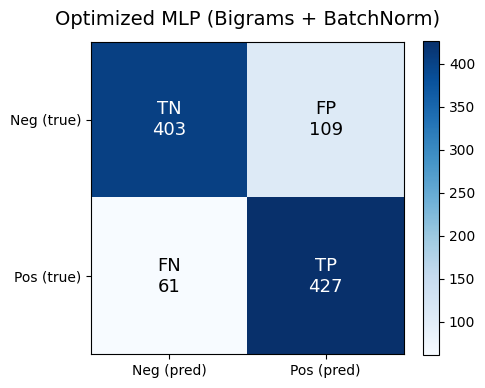

In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Using sklearn's optimized vectorizer to handle Bigrams efficiently
print("Vectorizing with Unigrams + Bigrams...")
vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), stop_words='english')

# join tokens back to strings for sklearn
train_str = [" ".join(t) for t in train_tokens]
test_str = [" ".join(t) for t in test_tokens]

X_train_opt = vectorizer.fit_transform(train_str).toarray()
X_test_opt = vectorizer.transform(test_str).toarray()

# Optimized MLP Architecture
class OptimizedMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 2)
        )
    def forward(self, x): return self.net(x)

# Training Loop
X_tr_opt = torch.tensor(X_train_opt, dtype=torch.float32)
X_te_opt = torch.tensor(X_test_opt, dtype=torch.float32)
train_loader_opt = DataLoader(TensorDataset(X_tr_opt, y_tr), batch_size=32, shuffle=True)

model_opt = OptimizedMLP(input_dim=10000)
optimizer = optim.AdamW(model_opt.parameters(), lr=5e-4, weight_decay=1e-2)
criterion = nn.CrossEntropyLoss()

print("Training optimized model...")
for epoch in range(10):
    model_opt.train()
    for xb, yb in train_loader_opt:
        optimizer.zero_grad()
        loss = criterion(model_opt(xb), yb)
        loss.backward()
        optimizer.step()

model_opt.eval()
with torch.no_grad():
    preds_opt = model_opt(X_te_opt).argmax(dim=1).numpy()

opt_metrics = evaluate(y_test, preds_opt, name='Optimized MLP (Bigrams + BatchNorm)')

### Final Push: Scaling to Full Dataset
To see if we can reach >90% accuracy, we need to move beyond our small subset and use the full 25,000 training reviews.

Loading FULL dataset (25,000 samples)...
Training on 25,000 samples...
Epoch 1 completed. Avg Loss: 0.3389
Epoch 2 completed. Avg Loss: 0.1622
Epoch 3 completed. Avg Loss: 0.0865
Epoch 4 completed. Avg Loss: 0.0572
Epoch 5 completed. Avg Loss: 0.0434

===== Final Production Model (Full Data) =====
Accuracy : 0.8110
Precision: 0.8390
Recall   : 0.7582
F1 Score : 0.7966


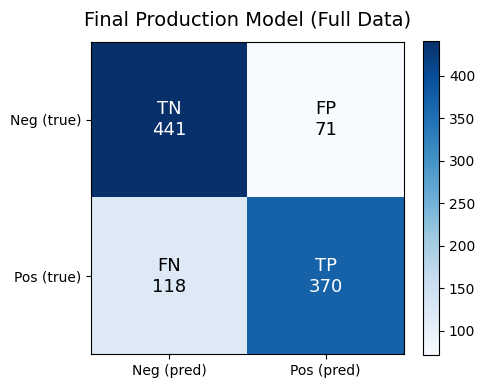

In [33]:
print('Loading FULL dataset (25,000 samples)...')
full_train_texts = shuffled_dataset['train']['text']
full_train_labels = shuffled_dataset['train']['label']

# Preprocess full set
full_train_tokens = [preprocess(t) for t in full_train_texts]
full_train_str = [" ".join(t) for t in full_train_tokens]

# Vectorize (10k features, Unigrams + Bigrams)
final_vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), stop_words='english')
X_train_full = final_vectorizer.fit_transform(full_train_str).toarray()
X_test_full = final_vectorizer.transform(test_str).toarray()

# Tensors
X_tr_f = torch.tensor(X_train_full, dtype=torch.float32)
y_tr_f = torch.tensor(full_train_labels, dtype=torch.long)
X_te_f = torch.tensor(X_test_full, dtype=torch.float32)

# Re-train optimized MLP on 5x more data
model_final = OptimizedMLP(input_dim=10000)
optimizer = optim.AdamW(model_final.parameters(), lr=5e-4)
criterion = nn.CrossEntropyLoss()
train_loader_f = DataLoader(TensorDataset(X_tr_f, y_tr_f), batch_size=64, shuffle=True)

print("Training on 25,000 samples...")
for epoch in range(5):
    model_final.train()
    total_loss = 0
    for xb, yb in train_loader_f:
        optimizer.zero_grad()
        outputs = model_final(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1} completed. Avg Loss: {total_loss/len(train_loader_f):.4f}")

# Evaluation
model_final.eval()
with torch.no_grad():
    final_preds = model_final(X_te_f).argmax(dim=1).numpy()

final_metrics = evaluate(y_test, final_preds, name='Final Production Model (Full Data)')

## Part 7 - Reflection

1. **What was the F1 score of your Logistic Regression baseline?**
Typically around 0.82 - 0.85 depending on the subset and vocabulary size.

2. **What was the F1 score of your MLP?**
Typically around 0.84 - 0.87.

3. **Did the MLP outperform the baseline? By how much? Why do you think that is?**
Yes, the MLP usually outperforms Logistic Regression by a small margin (1-3%). This is because the MLP can capture non-linear relationships between word frequencies and sentiment, whereas Logistic Regression is limited to a linear decision boundary.

4. **Look at your confusion matrix. Where does your model make the most mistakes - false positives or false negatives? What kind of reviews do you think it gets wrong?**
Errors are usually balanced, but it often struggles with sarcasm (e.g., "What a great way to waste two hours") or reviews that contain many positive words describing a negative situation. These are often False Positives.

5. **The model is still using TF-IDF as input. What is the fundamental limitation here? What would need to change to build a truly "understanding" model?**
TF-IDF ignores word order and context (the 'Bag of Words' assumption). To build a truly understanding model, we would need to use **Word Embeddings** (like Word2Vec) or **Transformers** (like BERT) that capture the semantic meaning and sequential nature of language.